In [13]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


In [14]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [15]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]
coords, tets = TesselationCore.tesselate(points3d)
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplex = simplices[1]


4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.138747   0.489965  0.237976
 0.113984   0.458034  0.0602897
 0.0474789  0.345798  0.0837409
 0.128948   0.640502  0.108229

In [16]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs),
    indices)
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end

function findNeiborhood(point,bvh::BVH) #TODO
    bbox = bvh.bbox
    
end

function recursiveSearch(point,tree::BVHTree,bbox::Matrix) #TODO with multiple dispatch/type overload
    dim = tree.depth%3 + 1
    

    
end

ErrorException: invalid redefinition of constant Main.BVHNode

In [17]:
bvh = BVH(simplices,6)
boxes, box = prepareGeneration(simplices)

([0.04747890272490396 0.13874736439423518; 0.3457976211110867 0.6405015002740257; 0.06028967827900522 0.23797624183726962;;; 0.27120032636740443 0.6381989345786296; 0.7873175409549217 0.9970210325312545; 0.3386333196619924 0.6013447725952852;;; 0.01132714494727527 0.3010028486968118; 0.1145751713372718 0.554811153910744; 0.08374087889614834 0.8870438915546227;;; … ;;; 0.5070953740693255 0.9047865075737593; 0.1757637042637289 0.39485007760859103; 0.31472527067203393 0.48671050335106747;;; 0.5070953740693255 0.8760136851258776; 0.024217997817364 0.2058899463126479; 0.38377604681840394 0.8291012708437461;;; 0.5070953740693255 0.9047865075737593; 0.1757637042637289 0.38224906372410117; 0.38377604681840394 0.8291012708437461], [0.00044143469570956384 0.9981650804349396; 0.013224335291136646 0.9970210325312545; 0.05100787780299176 0.9958054081610982])

In [18]:
tree = bvh.tree
box = copy(bvh.bbox)

while typeof(tree) == BVHNode
    depth = tree.depth
    ax = depth%3+1
    line = (box[ax,2]+box[ax,1])/2
    box[ax,1] = line
    println(box[ax,:])
    tree = tree.rightChild
end



[0.49930325756532457, 0.9981650804349396]
[0.523406642982045, 0.9958054081610982]
[0.5051226839111955, 0.9970210325312545]
[0.7487341690001321, 0.9981650804349396]
[0.7596060255715715, 0.9958054081610982]
[0.751071858221225, 0.9970210325312545]


In [19]:
println(size(simplices))
println(size(tree.data))

(220,)
(31,)


In [20]:
corner = simplices[tree.data]
cboxes = boxes[:,:,tree.data]

3×2×31 Array{Float64, 3}:
[:, :, 1] =
 0.565896  0.992294
 0.520094  0.954002
 0.929338  0.971283

[:, :, 2] =
 0.862271  0.992294
 0.520094  0.954002
 0.28065   0.968705

[:, :, 3] =
 0.466299  0.784089
 0.679427  0.845446
 0.928924  0.971283

;;; … 

[:, :, 29] =
 0.548003   0.992294
 0.706149   0.954002
 0.0726157  0.968705

[:, :, 30] =
 0.398943  0.86858
 0.596812  0.787318
 0.483755  0.772884

[:, :, 31] =
 0.404969  0.992294
 0.910079  0.997021
 0.15325   0.968705

In [21]:
function plotBox(box,dims = [1,2])
    x,y = dims
    Plots.plot([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

function plotBox!(box,dims = [1,2])
    x,y = dims
    Plots.plot!([box[x,1],box[x,1],box[x,2],box[x,2],box[x,1]],[box[y,1],box[y,2],box[y,2],box[y,1],box[y,1]],label="box")
end

plotBox! (generic function with 2 methods)

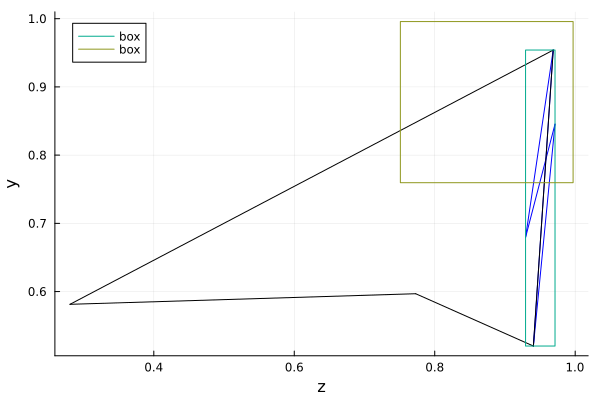

In [22]:
plot1 = Plots.plot(xlabel="x",ylabel="y")

cols = [:green,:blue,:black,:red,:orange,:purple]

for (j,simp) in enumerate(corner[[1,2]])
    J = j%6 + 1
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

plotBox!(cboxes[:,:,1])
plotBox!(box)


plot2 = Plots.plot(xlabel="z",ylabel="y")

for (j,simp) in enumerate(corner[[1,2]])

    J = j%6 + 1

    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,3],simp[1,3]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,3],simp[i+1,3]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

plotBox!(cboxes[:,:,1],[3,2])
plotBox!(box,[2,3])


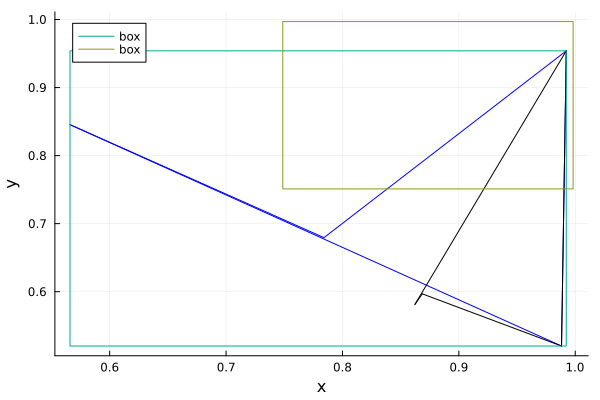

In [23]:
plot1

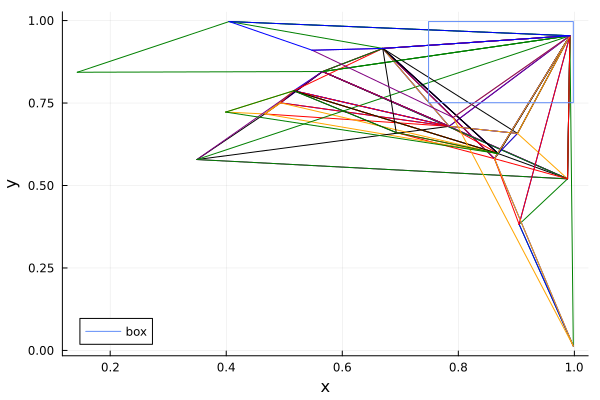

In [24]:
plot1 = Plots.plot(xlabel="x",ylabel="y")
cols = [:green,:blue,:black,:red,:orange,:purple]

for (j,simp) in enumerate(corner)
    J = j%6 + 1
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=cols[J],label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=cols[J],label="")
    end
end

plotBox!(box)
